# BPT Plotting Code

Settings for the plots

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib widget



# ==========================  Plot Setting  ========================== #

# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('font', weight='bold')
plt.rc('text', usetex=True)

# ------- Cosmology palette (normalized RGB) ------- v1
"""
COSMO_COLORS = {
    "color1": (120/255, 120/255, 120/255), #cool gray
    "color2": (150/255, 40/255, 40/255), #soft crimson
    "color3": (200/255, 140/255, 0/255), #warm gold
    "color4": (0/255, 110/255, 110/255), #dark teal
    "color5": (30/255, 60/255, 120/255), #deep blue
    }
"""
# ------- Cosmology palette (normalized RGB) ------- v2
COSMO_COLORS = {
    "color1": (241/255, 222/255, 222/255), #soft cream
    "color2": (212/255, 150/255, 167/255), #warm rose
    "color3": (93/255, 87/255, 107/255), #deep gray
    "color4": (255/255, 151/255, 107/255), #warm coral
    "color5": (108/255, 212/255, 254/255), #cool sky blue
    }


sns.set_theme(
    style="ticks",
    context='paper',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["color1"],
    COSMO_COLORS["color2"],
    COSMO_COLORS["color3"],
    COSMO_COLORS["color4"],
    COSMO_COLORS["color5"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes

## Simple plots by source


We can select weather plotting the arrows, the labels, showing the plot or just information on the ratio of the lines. This is mostly for interactive and visualization's sake.

ID           1.000511e+07
red_axis    -3.796371e-01
blue_axis    9.215461e-01
EW JADES     1.368427e+03
Name: 46, dtype: float64


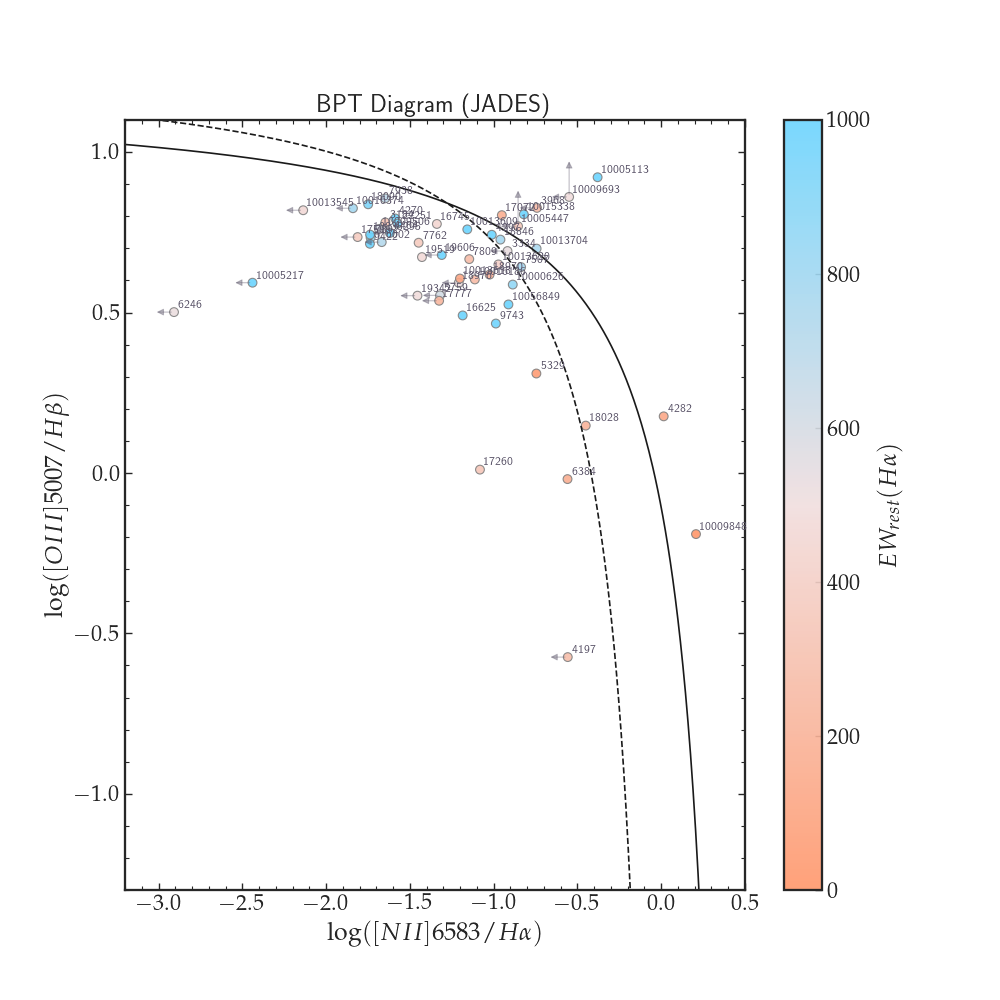

In [20]:
import numpy as np
import pandas as pd


def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/LF_all_filters_last.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')
    

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }
    
    return pd.DataFrame(result)
#====================================================================#
#====================================================================#

def plt_bpt(source='JADES', arrows=True, labels=True, save=False, show=True, index=60):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']
    keys = ['ID', 'redshift', f'EW {source}']
    
    # Keep only rows common to all three dataframes 
    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner').merge(df_395H[keys], on=keys, how='inner')
    )
    
    # Align each dataframe to the common keys
    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    # Start from common ID/redshift
    df_final = base.copy()
    
    # Priority: df_235 -> df_395 -> df_395H -> NaN
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']


    # Kewley maximum starburst line-
    x_kewly = np.linspace(-3.5, 0.25, 500)
    x_kauff = np.linspace(-3.5, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(10, 10))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-3.2, 0.5)
    plt.ylim(-1.3, 1.1)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()
    plt.grid(False)

    xf=df_final['red_axis']
    yf=df_final['blue_axis']

    

    # Custom colormap: gray → red
    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
    )
    
    scatter = plt.scatter(
        xf, yf,
        s=40,
        c=df_final['EW MAST'] if source == 'MAST' else df_final['EW JADES'],
        cmap=gray_red_cmap,
        edgecolor='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')


    if labels:
        for x, y, obj_id in zip(xf, yf, df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['color3']
            )

    
    
    if arrows:
        for x, y in zip(xf[df_final['red_err']], yf[df_final['red_err']] ):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['color3'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )

        
        for x, y in zip(xf[df_final['blue_err']], yf[df_final['blue_err']] ):
            plt.annotate(
                '',
                xy=(x, y+0.12),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['color3'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )
    
    
    if save:
        plt.savefig('bpt_jades_all_objects.pdf', bbox_inches='tight')

    
    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[46])
    plt.show()

    



plt_bpt(source='JADES', labels=True, arrows=True, show=True, index=32, save=False)

## MAST and JADES simultaneously

The following code allows us to plot them simulateneously along with the information they contain for object of given index. This was used to improve the results and during the analysis process of the results, not useful as a result itself.

In [ ]:
def main():

    df_mast = get_bpt_dataframe('MAST')
    df_jades = get_bpt_dataframe('JADES')

    common_ids = (
        set(df_mast.loc[df_mast[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID']) &
        set(df_jades.loc[df_jades[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID'])
    )

    df_mast_common = df_mast[df_mast['ID'].isin(common_ids)].reset_index(drop=True)
    df_jades_common = df_jades[df_jades['ID'].isin(common_ids)].reset_index(drop=True)

    plot_bpt_df(df_mast_common, 'MAST')
    plot_bpt_df(df_jades_common, 'JADES')

def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/LF_all_filters_last.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }
    
    return pd.DataFrame(result)
#====================================================================#
#====================================================================#


def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final

def plot_bpt_df(df_final, source, labels=True, arrows=True):
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0.0, 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    plt.figure(figsize=(10, 10))
    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.xlim(-2, 0.5)
    plt.ylim(-1., 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$')
    plt.minorticks_on()
    plt.grid(False)

    gray_red_cmap = LinearSegmentedColormap.from_list(
            'gray_red',
            [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
        )

    
    # plot all points as unfilled markers
    plt.scatter(
        df_final['red_axis'],
        df_final['blue_axis'],
        s=40,
        facecolors='none',
        edgecolors='grey',
        alpha=0.7,
        linewidths=0.8
    )

    # overlay only points with EW values using the color axis
    ew_mask = df_final[f'EW {source}'].notna()
    scatter = plt.scatter(
        df_final.loc[ew_mask, 'red_axis'],
        df_final.loc[ew_mask, 'blue_axis'],
        s=40,
        c=df_final.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')

    if labels:
        for x, y, obj_id in zip(df_final['red_axis'], df_final['blue_axis'], df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['color3']
            )

    if arrows:
        for x, y in zip(df_final.loc[df_final['red_err'], 'red_axis'],
                        df_final.loc[df_final['red_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['color3'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

        for x, y in zip(df_final.loc[df_final['blue_err'], 'red_axis'],
                        df_final.loc[df_final['blue_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x, y + 0.10),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['color3'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[18])
    plt.show()

main()


## MAST vs JADES Comparison result

The following plot is a result plot, that should appear in the paper. It displays the BPT diagram with all the candidates for JADES and MAST, side by side so that the reader spots the main differences, without condensing too much information. 

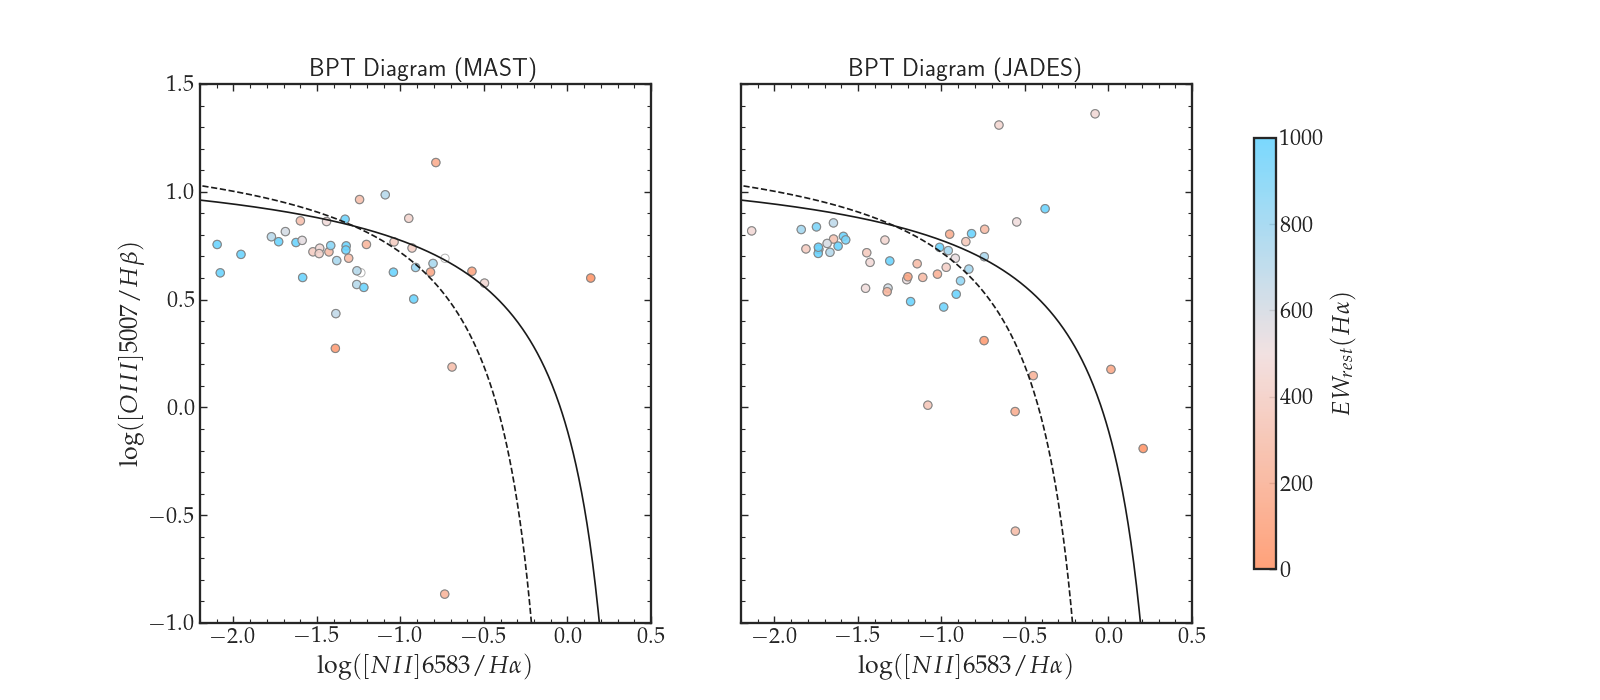

In [24]:
# side-by-side BPT for MAST and JADES with single colorbar
df_mast = get_bpt_dataframe('MAST')
df_jades = get_bpt_dataframe('JADES')

# keep only objects with both axes in both catalogs (as in previous logic)
common_ids = (
    set(df_mast.loc[df_mast[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID']) &
    set(df_jades.loc[df_jades[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID'])
)

df_mast_common = df_mast[df_mast['ID'].isin(common_ids)].reset_index(drop=True)
df_jades_common = df_jades[df_jades['ID'].isin(common_ids)].reset_index(drop=True)

x_kewly = np.linspace(-2.5, 0.25, 500)
x_kauff = np.linspace(-2.5, 0.0, 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3


gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
    )


vmin, vmax = 0, 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, df, source, title in zip(axes, [df_mast_common, df_jades_common], ['MAST','JADES'], ['MAST', 'JADES']):
    ax.plot(x_kewly, y_kewly, color='k')
    ax.plot(x_kauff, y_kauff, color='k', linestyle='--')
    ax.set_xlim(-2.2, 0.5)
    ax.set_ylim(-1.0, 1.5)
    ax.set_xlabel(r'$\log([NII]6583/H\alpha)$')
    if ax is axes[0]:
        ax.set_ylabel(r'$\log([OIII]5007/H\beta)$')
    ax.set_title(f'BPT Diagram ({title})')
    ax.grid(False)

    # base unfilled markers
    ax.scatter(df['red_axis'], df['blue_axis'], s=36, facecolors='none', edgecolors='grey', alpha=0.6, linewidths=0.7)
    ax.minorticks_on()

    # overlay colored points (only where EW exists)
    ew_mask = df[f'EW {source}'].notna()
    sc = ax.scatter(
        df.loc[ew_mask, 'red_axis'],
        df.loc[ew_mask, 'blue_axis'],
        s=36,
        c=df.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    # annotate IDs (optional; keep small)
    """
    for x, y, oid in zip(df['red_axis'], df['blue_axis'], df['ID']):
        ax.annotate(str(oid), (x, y), xytext=(3,3), textcoords='offset points', fontsize=7, color=COSMO_COLORS['deep_blue'])
    """
        
# single colorbar for both axes
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label(r'$EW_{rest}(H\alpha)$')

plt.savefig('./Output_data/bpt_mast_jades_comparison_paper.pdf', bbox_inches='tight')

plt.show()

## Including Local Sample, Exclude AGN

ID           5457.0
red_axis        NaN
blue_axis       NaN
EW MAST         NaN
Name: 7, dtype: float64


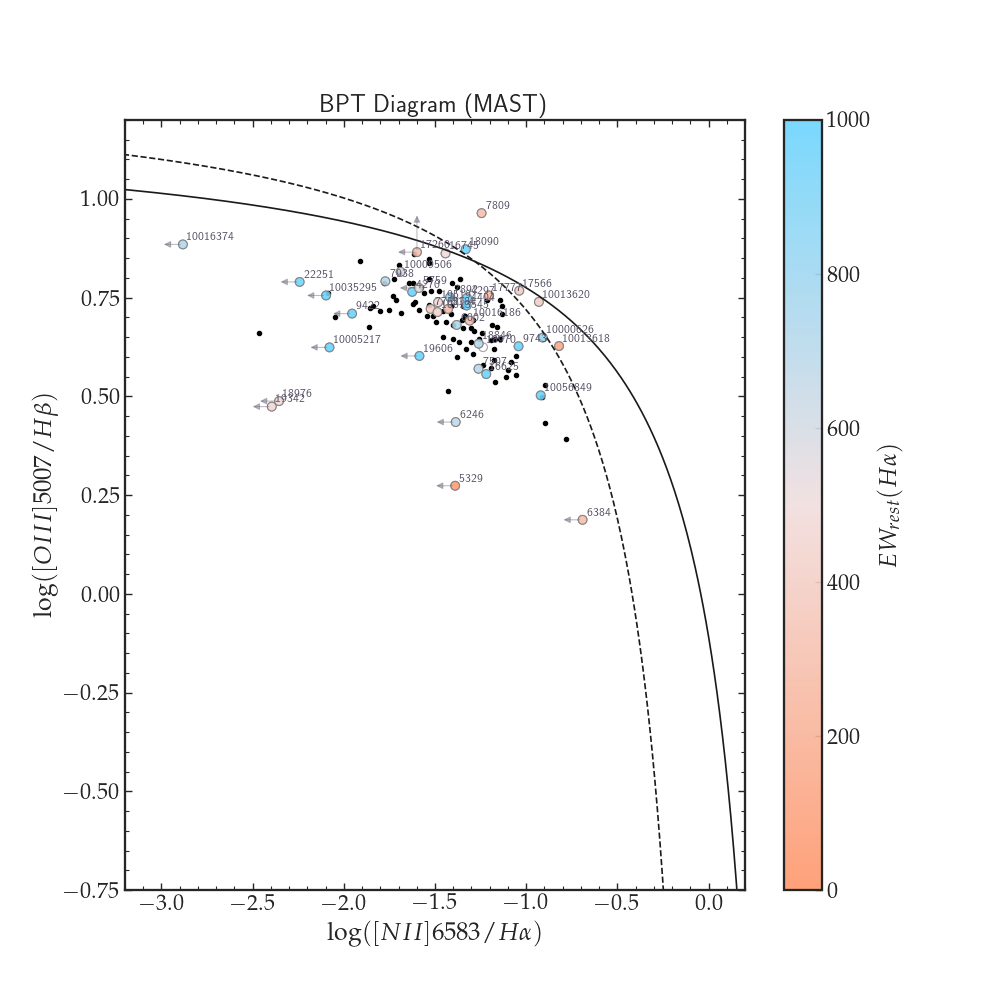

In [5]:
def main():
    exclude_ids = {3968, 4282, 9452, 17072, 18028, 10001587, 10001892, 10009848, 10005113, 10005447, 10009693, 10013704, 10015338}

    df_jades = get_bpt_dataframe('MAST')

    df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


    plot_bpt_df(df_jades_filtered, 'MAST', labels=True)
    #plt.savefig('Output_data/bpt_jades_HII_candidates.pdf', bbox_inches='tight')



def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final

def plot_bpt_df(df_final, source, labels=True, arrows=True):
    x_kewly = np.linspace(-3.5, 0.25, 500)
    x_kauff = np.linspace(-3.5, 0.0, 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    plt.figure(figsize=(10, 10))
    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.xlim(-3.2, 0.2)
    plt.ylim(-0.75, 1.2)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$')
    plt.minorticks_on()
    plt.grid(False)

    gray_red_cmap = LinearSegmentedColormap.from_list(
            'gray_red',
            [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
        )
        
    # plot all points as unfilled markers
    plt.scatter(
        df_final['red_axis'],
        df_final['blue_axis'],
        s=40,
        facecolors='none',
        edgecolors='grey',
        alpha=0.7,
        linewidths=0.8
    )
    
    localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
    sampĺe_red = localsample['red_axis']
    sample_blue = localsample['blue_axis']


    plt.scatter(
        sampĺe_red,
        sample_blue,
        color='black',
        s=10,
        edgecolor='black',
        alpha=1
    )


    # overlay only points with EW values using the color axis
    ew_mask = df_final[f'EW {source}'].notna()
    scatter = plt.scatter(
        df_final.loc[ew_mask, 'red_axis'],
        df_final.loc[ew_mask, 'blue_axis'],
        s=40,
        c=df_final.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')

    if labels:
        for x, y, obj_id in zip(df_final['red_axis'], df_final['blue_axis'], df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['color3']
            )

    if arrows:
        for x, y in zip(df_final.loc[df_final['red_err'], 'red_axis'],
                        df_final.loc[df_final['red_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['color3'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

        for x, y in zip(df_final.loc[df_final['blue_err'], 'red_axis'],
                        df_final.loc[df_final['blue_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x, y + 0.10),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['color3'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[7])

    
    plt.show()

main()

Now we include an inset to distinguish the dots in the region most populated. We can activate the labels, but the points are still too close together to be legible all of the times.

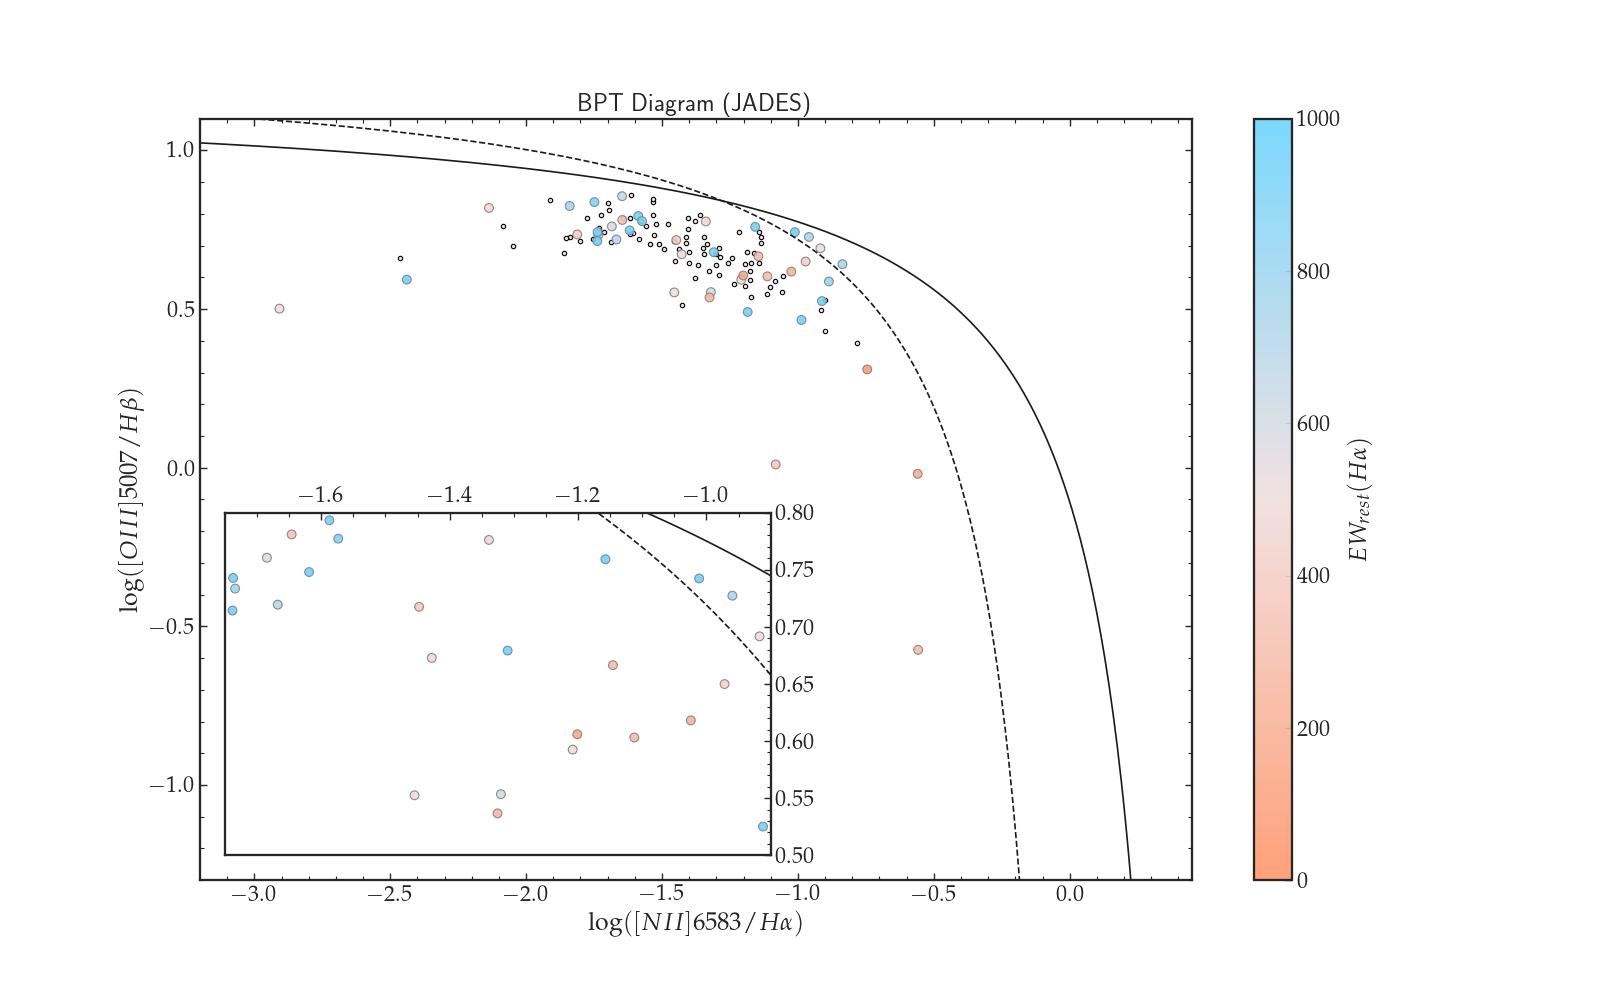

In [7]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

exclude_ids = {3968, 4282, 9452, 17072, 18028, 10001587, 10001892, 10009848, 10005113, 10005447, 10009693, 10013704, 10015338}

df_jades = get_bpt_dataframe('JADES')

df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


# Create the main plot
x_kewly = np.linspace(-3.5, 0.25, 500)
x_kauff = np.linspace(-3.5, 0., 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

fig, ax = plt.subplots(figsize=(16, 9.89))

ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-3.2, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([NII]6583/H\alpha)$')
ax.set_ylabel(r'$\log([OIII]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)

gray_red_cmap = LinearSegmentedColormap.from_list(
            'gray_red',
            [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
        )
    
localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color=COSMO_COLORS['color1'],
    s=10,
    edgecolor='black',
    alpha=1
)



scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
ax.set_title('BPT Diagram (JADES)')




# Create inset
axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.set_xlim(-1.75, -.9)
axins.set_ylim(0.5, 0.8)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()


"""
# Add labels to main plot
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

# Add labels to inset
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if -2 <= x <= -1 and 0 <= y <= 0.8:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""

plt.show()

Just to give more style to the plot, we can join the inset with the region in the plot it belongs to

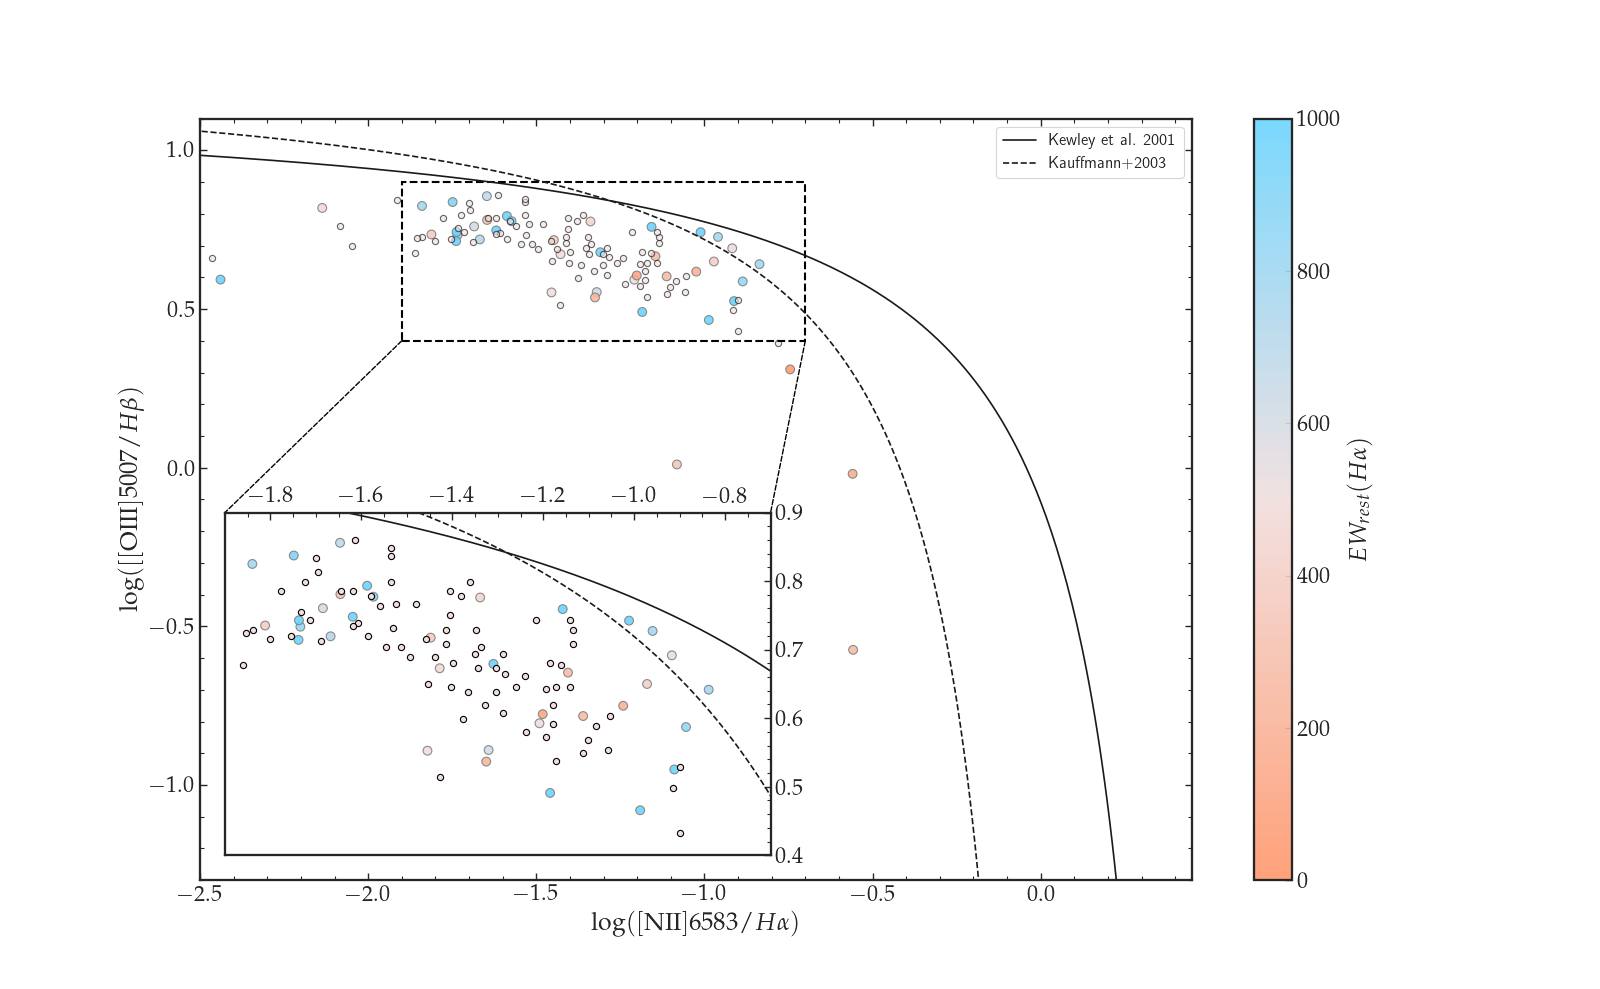

In [8]:
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

# rectangle region matching the inset limits
x0, x1 = -1.9, -0.7
y0, y1 = 0.4, 0.9

fig, ax = plt.subplots(figsize=(16, 9.89))

ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-2.5, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([\mathrm{NII}]6583/H \alpha)$')
ax.set_ylabel(r'$\log([\mathrm{[OIII}]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)
ax.legend()


gray_red_cmap = LinearSegmentedColormap.from_list(
            'gray_red',
            [COSMO_COLORS['color4'], COSMO_COLORS['color1'], COSMO_COLORS['color5']]
        )
    


scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
#ax.set_title('BPT Diagram (JADES)')

localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color=COSMO_COLORS['color1'],
    s=20,
    edgecolor='black',
    alpha=0.6
)


# add rectangle on the main plot
rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    fill=False
)
ax.add_patch(rect)

axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.scatter(
    sampĺe_red,
    sample_blue,
    color=COSMO_COLORS['color1'],
    s=20,
    edgecolor='black',
    alpha=1
)
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()




"""
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if x0 <= x <= x1 and y0 <= y <= y1:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""
connector1 = ConnectionPatch(
    xyA=(x0, y0),
    coordsA=ax.transData,
    xyB=(0, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=1
)
connector2 = ConnectionPatch(
    xyA=(x1, y0),
    coordsA=ax.transData,
    xyB=(1, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=1
)
ax.add_artist(connector1)
ax.add_artist(connector2)




plt.show()
#plt.savefig('bpt_jades_GH2026.pdf')

## BPT diagram for the thesis

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

%matplotlib widget
#================= Plot Settings =================#
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes



def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/LF_all_filters_last.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')
    

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES'],
        'EW MAST B': -1*equivalent_widths['EW(Hb) MAST'],
        'EW JADES B': -1*equivalent_widths['EW(Hb) JADES']
        
    }
    
    return pd.DataFrame(result)



def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final



# rectangle region matching the inset limits
x0, x1 = -1.9, -0.7
y0, y1 = 0.4, 0.9

fig, ax = plt.subplots(figsize=(16, 9.89))

x_kewly = np.linspace(-3.5, 0.25, 500)
x_kauff = np.linspace(-3.5, 0., 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3
ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-2.5, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([\mathrm{NII}]6583/H \alpha)$')
ax.set_ylabel(r'$\log([\mathrm{[OIII}]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)
ax.legend()

gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold'], COSMO_COLORS['soft_crimson']]
)

exclude_ids = {3334, 3968, 4197, 4282, 5329, 7624, 9452, 17072, 17260, 18028, 10001587, 10001892, 10005113, 10005447, 10009693, 10009848, 10013704, 10015338}
df_jades = get_bpt_dataframe('JADES')

df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
ax.set_title('BPT Diagram (JADES)')

localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color='grey',
    s=20,
    edgecolor='black',
    alpha=0.4
)


# add rectangle on the main plot
rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    fill=False
)
ax.add_patch(rect)



# Create the main plot
axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.scatter(
    sampĺe_red,
    sample_blue,
    color='grey',
    s=20,
    edgecolor='black',
    alpha=0.4
)
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()




"""
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if x0 <= x <= x1 and y0 <= y <= y1:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""
connector1 = ConnectionPatch(
    xyA=(x0, y0),
    coordsA=ax.transData,
    xyB=(0, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
connector2 = ConnectionPatch(
    xyA=(x1, y0),
    coordsA=ax.transData,
    xyB=(1, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
ax.add_artist(connector1)
ax.add_artist(connector2)




plt.show()

## Analysis for large-redshift objects in view of HII diagnosis

In [ ]:
n_bins = 12
counts, bins = np.histogram(df_jades_filtered['redshift'].dropna(), bins=n_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

cmap = LinearSegmentedColormap.from_list('gray_to_red', ['gray', COSMO_COLORS['soft_crimson']])
colors = cmap(np.linspace(0, 1, n_bins))

plt.figure(figsize=(8, 5))
plt.bar(
    bin_centers,
    counts,
    width=np.diff(bins),
    color=colors,
    edgecolor='black',
    align='center'
)
plt.xlabel('redshift')
plt.ylabel('Counts')
plt.grid(False)

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
blue_axis_filtered = df_jades_filtered['blue_axis'].dropna()
blue_axis_filtered = blue_axis_filtered[blue_axis_filtered >= 0.4]

plt.hist(blue_axis_filtered, bins=15, edgecolor='black', color=COSMO_COLORS['deep_blue'], alpha=0.7)
plt.xlabel(r'$\log([\mathrm{OIII}]5007/H\beta)$')
plt.ylabel('Counts')

plt.grid(False)

mean_val = blue_axis_filtered.mean()
std_val = blue_axis_filtered.std()
plt.text(0.98, 0.97, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

In [ ]:
df_jades_b = compute_axes(source='JADES', filter='G395M')

plt.figure(figsize=(8, 6))
plt.scatter(
    df_jades_b['EW JADES B'],
    df_jades_b['blue_axis'],

    edgecolor='black',
    alpha=0.75
)
plt.xlabel('EW B (JADES)')
plt.ylabel(r'$\log([\mathrm{OIII}]5007/H\beta)$')
plt.grid(False)
plt.show()